# Independent Project 1: Representation, Similarity, Clusters, Density & Anomalies
**100 points · 10 questions × 10**

Per question: **experiment executed & numbers reported (5)** · **explanation (5)**.
All formulas you need are printed in the Word handout.

In [2]:
# ---- Setup (run once) ----
%pip uninstall -y numpy scipy

!rm -rf \
  /usr/local/lib/python3.12/dist-packages/numpy \
  /usr/local/lib/python3.12/dist-packages/numpy.libs \
  /usr/local/lib/python3.12/dist-packages/numpy-*.dist-info \
  /usr/local/lib/python3.12/dist-packages/scipy \
  /usr/local/lib/python3.12/dist-packages/scipy.libs \
  /usr/local/lib/python3.12/dist-packages/scipy-*.dist-info

%pip install -q --no-cache-dir \
  "numpy==2.2.6" \
  "scipy==1.15.3" \
  "scanpy==1.11.4" \
  "igraph==0.11.8" \
  "leidenalg==0.10.2"

Found existing installation: numpy 2.2.6
Uninstalling numpy-2.2.6:
  Successfully uninstalled numpy-2.2.6
Note: you may need to restart the kernel to use updated packages.


'rm' is not recognized as an internal or external command,
operable program or batch file.


^C
Note: you may need to restart the kernel to use updated packages.


In [7]:
import numpy as np, hashlib
import matplotlib.pyplot as plt
import scanpy as sc
from scipy.stats import spearmanr
from scipy.special import rel_entr
from sklearn.neighbors import NearestNeighbors, LocalOutlierFactor
from sklearn.metrics import adjusted_rand_score

np.random.seed(0); sc.settings.verbosity = 1
FALLBACK = set()          # e.g. FALLBACK.add("Q4") if an assert defeats you

adata = sc.datasets.pbmc3k(); adata.var_names_make_unique()
adata.layers["counts"] = adata.X.copy()
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)
print(adata.shape)

c:\Users\wages\AppData\Local\Programs\Python\Python311\Lib\site-packages\scanpy\_utils\__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\wages\AppData\Local\Programs\Python\Python311\Lib\site-packages\scanpy\__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
c:\Users\wages\AppData\Local\Programs\Python\Python311\Lib\site-packages\scanpy\readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
c:\Users\wages\AppData\Local\Programs\Python\Python311\Lib\site-packages\scanpy\datasets\_utils.py:35: FutureWarning:

(2700, 32738)


---
## Question 1 (10 pts):

In [ ]:
def normalize_depth(X, target=1e4):
    """X: dense (n_cells x n_genes) raw counts. Scale each ROW to sum to `target`."""
    # TODO(1): implement per the handout formula
    for i in range(X.shape[0]): # shape[0] is the number of rows (cells)
        row_sum = np.sum(X[i, :])
        if row_sum > 0:
            X[i, :] = (X[i, :] / row_sum) * target
    return X
    raise NotImplementedError

def log1p_np(X):
    # TODO(2): elementwise ln(1 + x)
    Y = X.copy()
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            Y[i, j] = np.log1p(Y[i, j])
    return Y
    raise NotImplementedError

# ---- assert: match scanpy on a 200-cell dense subset ----
X_sub = adata.layers["counts"][:200].toarray()
mine  = log1p_np(normalize_depth(X_sub, 1e4))
ref_a = sc.AnnData(X_sub.copy()); sc.pp.normalize_total(ref_a, target_sum=1e4); sc.pp.log1p(ref_a)
assert np.allclose(mine, ref_a.X, atol=1e-5), "Q1 assert FAILED - check row sums / log placement"
print("Q1 assert PASSED")

Q1 assert PASSED


In [10]:
sc.pp.normalize_total(adata, target_sum=1e4); sc.pp.log1p(adata)

# ---- EXPERIMENT: hub-ness vs depth, raw vs normalized (given except one TODO) ----
rng = np.random.RandomState(0)
sub = rng.choice(adata.n_obs, 300, replace=False)
RAW  = adata.layers["counts"][sub].toarray()
NORM = adata.X[sub].toarray() if hasattr(adata.X, "toarray") else adata.X[sub]
depth = RAW.sum(1)

def top10_sets(M):
    idx = NearestNeighbors(n_neighbors=11).fit(M).kneighbors(M)[1][:, 1:]
    return idx

idx_raw, idx_norm = top10_sets(RAW), top10_sets(NORM)
overlap = [len(set(a) & set(b)) / len(set(a) | set(b)) for a, b in zip(idx_raw, idx_norm)]
print("mean Jaccard(raw-neighbors, norm-neighbors) =", round(float(np.mean(overlap)), 3))

# TODO(3): in-degree = how often each cell appears in OTHERS' top-10 (hint: np.bincount(idx.ravel(), minlength=300))
indeg_raw  = np.bincount(idx_raw.ravel(), minlength=300)  # ____________________
indeg_norm = np.bincount(idx_norm.ravel(), minlength=300)  # ____________________
print("Spearman(depth, in-degree)  raw :", spearmanr(depth, indeg_raw).statistic.round(3))
print("Spearman(depth, in-degree)  norm:", spearmanr(depth, indeg_norm).statistic.round(3))

mean Jaccard(raw-neighbors, norm-neighbors) = 0.101
Spearman(depth, in-degree)  raw : -0.241
Spearman(depth, in-degree)  norm: -0.185


**1.	Compare the two Spearman correlations. What do they suggest about the relationship between cell depth and neighbor selection before and after normalization? Support your interpretation with both values.**



**2.	Suppose the analysis used only raw-count L2 distance. Based on your results, what kinds of cells would you expect to appear in the same neighborhoods? Which cells, if any, would be selected unusually often as neighbors, and why?**

---
## Question 2 (10 pts):

In [12]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

topics = ["bio"]*8 + ["finance"]*8 + ["sports"]*8
corpus = [
 "single cell rna sequencing measures gene expression in individual cells",
 "gene expression profiles let us compare individual cells directly",
 "clustering groups cells with similar expression profiles together",
 "anomaly detection flags cells whose profiles differ from every group",
 "mitochondrial genes indicate stressed or dying cells in the sample",
 "normalization removes sequencing depth artifacts from cell profiles",
 "marker genes identify the biological type of each cell cluster",
 "dimensionality reduction embeds cells into a low dimensional space",
 "stock markets rallied today as technology shares surged on earnings",
 "investors sold technology shares when the market fell after earnings",
 "the central bank raised interest rates to slow rising inflation",
 "bond yields climbed while equity markets retreated on rate fears",
 "the company reported quarterly earnings above analyst expectations",
 "currency traders reacted to the surprise inflation report today",
 "retail investors piled into index funds during the market rally",
 "analysts downgraded the stock citing weak forward guidance",
 "the home team scored twice in the final minutes to win the match",
 "the goalkeeper made a stunning save during the penalty shootout",
 "the coach praised the defense after a hard fought away victory",
 "fans celebrated as the striker completed a first half hattrick",
 "the midfielder was injured and will miss the championship final",
 "the club signed a new forward during the winter transfer window",
 "a late corner kick led to the decisive goal of the tournament",
 "the referee awarded a controversial penalty in extra time",
]

def my_tfidf(corpus):
    """Return (n_docs x n_terms) matrix matching sklearn's TfidfVectorizer defaults."""
    cv = CountVectorizer() 
    Cnt = cv.fit_transform(corpus).toarray().astype(float)
    N = Cnt.shape[0]
    # TODO(1): df, smooth idf  (handout: idf = ln((1+N)/(1+df)) + 1)
    idf = np.log((1 + N) / (1 + np.sum(Cnt > 0, axis=0))) + 1  # ____________________
    # TODO(2): weight = count * idf, then L2-normalize each ROW
    W = Cnt * idf  # ____________________
    # L2-normalize each row
    W = W / np.linalg.norm(W, axis=1, keepdims=True)
    return W, cv

W, cv = my_tfidf(corpus)
ref = TfidfVectorizer().fit_transform(corpus).toarray()
assert np.allclose(W, ref, atol=1e-6), "Q2 assert FAILED - check smooth idf and row normalization"
print("Q2 assert PASSED")

Q2 assert PASSED


In [26]:
# ---- EXPERIMENT: leave-one-out nearest-neighbor topic accuracy (given except two one-liners) ----
Cnt = CountVectorizer().fit_transform(corpus).toarray().astype(float)

def dist_l2(A):        # pairwise L2 distance matrix
    # TODO(3): ____________________  (hint: broadcasting or (a-b)^2 = a^2+b^2-2ab)
    return np.sqrt(np.sum(A**2, axis=1)[:, np.newaxis] + np.sum(A**2, axis=1)[np.newaxis, :] - 2 * A @ A.T)
    raise NotImplementedError

def sim_cos(A):        # pairwise cosine similarity matrix
    # TODO(4): ____________________
    return A @ A.T / (np.linalg.norm(A, axis=1)[:, np.newaxis] * np.linalg.norm(A, axis=1)[np.newaxis, :])
    raise NotImplementedError

def loo_accuracy(M, use_similarity):
    S = sim_cos(M) if use_similarity else -dist_l2(M)
    np.fill_diagonal(S, -np.inf)
    nn = S.argmax(1)
    return np.mean([topics[i] == topics[j] for i, j in enumerate(nn)])

print("counts + L2      LOO accuracy:", round(loo_accuracy(Cnt, False), 3))
print("tf-idf + cosine  LOO accuracy:", round(loo_accuracy(W,   True ), 3))

counts + L2      LOO accuracy: 0.875
tf-idf + cosine  LOO accuracy: 0.792


**1.	Report the accuracy of both configurations and calculate the difference between them. Which configuration performs better? Using evidence from the corpus, explain what properties of its representation and comparison measure may account for the difference.**


**2.	Construct two sentences that have the same bag-of-words representation but communicate different meanings. What information has been lost, and why would changing the term weights not recover it?**

---
## Question 3 (10 pts):

In [15]:
# standard pipeline to PCA (given)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
adata_hvg = adata[:, adata.var.highly_variable].copy()
sc.pp.scale(adata_hvg, max_value=10)
sc.tl.pca(adata_hvg, n_comps=50, svd_solver="arpack")
Z = adata_hvg.obsm["X_pca"]

def pairwise_l2(A, B):
    # TODO(1): (len(A) x len(B)) Euclidean distances, no python loops
    return np.sqrt(np.sum(A**2, axis=1)[:, np.newaxis] + np.sum(B**2, axis=1) - 2 * np.dot(A, B.T))
    raise NotImplementedError

def pairwise_cosdist(A, B):
    # TODO(2): 1 - cosine similarity
    return 1 - (np.dot(A, B.T) / (np.linalg.norm(A, axis=1)[:, np.newaxis] * np.linalg.norm(B, axis=1)))
    raise NotImplementedError

def topk(D_row, k):
    # TODO(3): indices of the k smallest entries, EXCLUDING index of the query itself if present
    indicies = np.argsort(D_row)[:k]
    return indicies  # Exclude the index of the query
    raise NotImplementedError

q = 0
d_l2  = pairwise_l2(Z[q:q+1], Z).ravel();  d_l2[q]  = np.inf
d_cos = pairwise_cosdist(Z[q:q+1], Z).ravel(); d_cos[q] = np.inf
my_l2, my_cos = set(topk(d_l2, 10)), set(topk(d_cos, 10))

ref_l2  = set(NearestNeighbors(n_neighbors=11, metric="euclidean").fit(Z).kneighbors(Z[q:q+1])[1].ravel()[1:])
ref_cos = set(NearestNeighbors(n_neighbors=11, metric="cosine"   ).fit(Z).kneighbors(Z[q:q+1])[1].ravel()[1:])
print("my_l2  =", my_l2)
print("my_cos  =", my_cos)
print("ref_l2  =", ref_l2)
print("ref_cos  =", ref_cos)
assert my_l2 == ref_l2 and my_cos == ref_cos, "Q3 assert FAILED"
print("Q3 assert PASSED")

c:\Users\wages\AppData\Local\Programs\Python\Python311\Lib\functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
c:\Users\wages\AppData\Local\Programs\Python\Python311\Lib\site-packages\scanpy\preprocessing\_pca\__init__.py:245: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  Version(ad.__version__) < Version("0.9")


my_l2  = {np.int64(739), np.int64(2660), np.int64(1380), np.int64(2021), np.int64(584), np.int64(430), np.int64(2130), np.int64(473), np.int64(283), np.int64(1756)}
my_cos  = {np.int64(1409), np.int64(1441), np.int64(739), np.int64(1380), np.int64(2021), np.int64(840), np.int64(392), np.int64(976), np.int64(473), np.int64(1371)}
ref_l2  = {np.int64(739), np.int64(2660), np.int64(1380), np.int64(2021), np.int64(584), np.int64(430), np.int64(2130), np.int64(473), np.int64(283), np.int64(1756)}
ref_cos  = {np.int64(1409), np.int64(1441), np.int64(739), np.int64(1380), np.int64(2021), np.int64(840), np.int64(392), np.int64(976), np.int64(473), np.int64(1371)}
Q3 assert PASSED


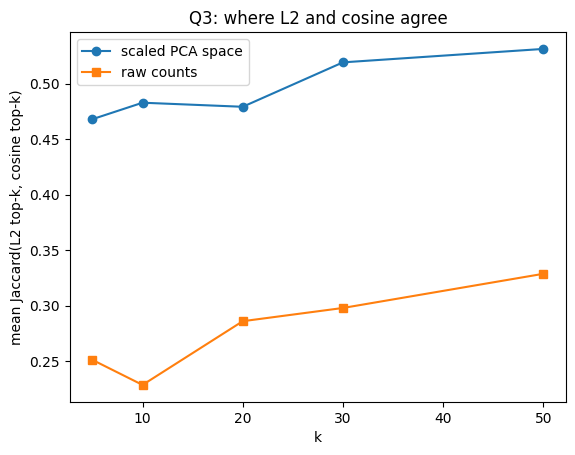

scaled: [0.468 0.483 0.479 0.519 0.531]  raw: [0.251 0.228 0.286 0.298 0.329]


In [16]:
# ---- EXPERIMENT: overlap curves, scaled-PCA space vs raw-count space (given) ----
rng = np.random.RandomState(1); qs = rng.choice(adata.n_obs, 60, replace=False)
RAW800 = adata.layers["counts"][:800].toarray(); qs800 = qs[qs < 800]

def overlap_curve(M, queries, ks):
    nl2  = NearestNeighbors(n_neighbors=max(ks)+1, metric="euclidean").fit(M)
    ncos = NearestNeighbors(n_neighbors=max(ks)+1, metric="cosine").fit(M)
    il2, icos = nl2.kneighbors(M[queries])[1][:,1:], ncos.kneighbors(M[queries])[1][:,1:]
    out = []
    for k in ks:
        ov = [len(set(a[:k]) & set(b[:k])) / len(set(a[:k]) | set(b[:k])) for a, b in zip(il2, icos)]
        out.append(np.mean(ov))
    return out

ks = [5, 10, 20, 30, 50]
c_scaled = overlap_curve(Z, qs, ks)
c_raw    = overlap_curve(RAW800, qs800, ks)
plt.plot(ks, c_scaled, "o-", label="scaled PCA space"); plt.plot(ks, c_raw, "s-", label="raw counts")
plt.xlabel("k"); plt.ylabel("mean Jaccard(L2 top-k, cosine top-k)"); plt.legend(); plt.title("Q3: where L2 and cosine agree"); plt.show()
print("scaled:", np.round(c_scaled, 3), " raw:", np.round(c_raw, 3))

**1.	In which representation do L2 and cosine produce more similar neighborhoods? Cite at least two values from your results, including the corresponding neighborhood sizes.**


**2.	How do the properties of scaled PCA features and raw counts help explain the difference between the two curves? Relate your answer to what L2 and cosine emphasize.**



**3.	Select one preprocessing step used before PCA. If that step were removed, how would you expect the agreement curve to change? Explain what information would be restored or altered and how that change could affect neighbor selection.**

---
## Question 4 (10 pts):

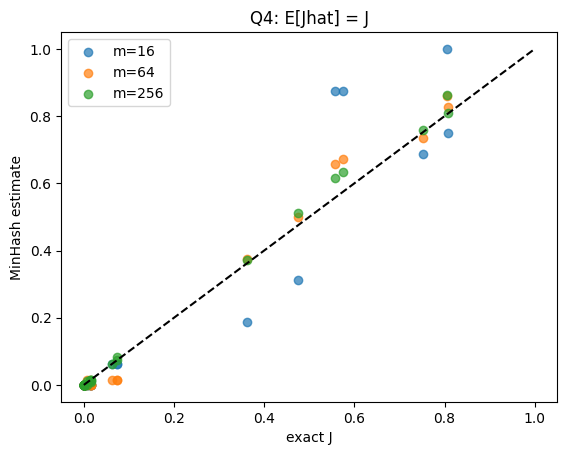

Q4 asserts PASSED | mean abs error by m: {16: 0.031, 64: 0.013, 256: 0.006}
pairs with exact J > 0.5: [('A', 'B'), ('A', 'C'), ('B', 'C'), ('E', 'F'), ('H', 'I')]


In [18]:
docs = {
 "A": "the quick brown fox jumps over the lazy dog near the river bank at dawn",
 "B": "the quick brown fox leaps over the lazy dog near the river bank at dawn",
 "C": "near the river bank at dawn the lazy dog was jumped over by the quick brown fox",
 "D": "a slow red fox walked past the sleeping dog far from the river at noon",
 "E": "stock markets rallied today as technology shares surged on strong earnings news",
 "F": "technology shares surged on strong earnings news as stock markets rallied today",
 "G": "stock markets fell today as technology shares slid on weak earnings news",
 "H": "researchers proposed a new clustering method for large single cell datasets",
 "I": "a new clustering method for large single cell datasets was proposed by researchers",
 "J": "the referee awarded a controversial penalty during the championship final",
}

def h(s, seed):
    salt = str(seed).encode()[:16].ljust(16, b"0")
    return int.from_bytes(hashlib.blake2b(s.encode(), digest_size=8, salt=salt).digest(), "big")

def shingles(text, k=5):
    t = " ".join(text.lower().split())
    # TODO(1): set of all character k-grams
    shingle_set = set()
    for i in range(len(t) - k + 1):
        shingle_set.add(t[i:i+k])
    return shingle_set

def jaccard(a, b):
    # TODO(2)
    intersection = len(a.intersection(b))
    union = len(a.union(b))
    return intersection / union if union != 0 else 0.0
    raise NotImplementedError

def minhash_signature(S, m):
    # TODO(3): signature[i] = min over shingles s of h(s, i), for i = 0..m-1
    return [min(h(s, i) for s in S) for i in range(m)]
    raise NotImplementedError

def estimate_J(sigA, sigB):
    # TODO(4): fraction of positions where the signatures agree
    return np.mean([1 if a == b else 0 for a, b in zip(sigA, sigB)])
    raise NotImplementedError

S = {k: shingles(v) for k, v in docs.items()}
assert jaccard(S["A"], S["A"]) == 1.0
names = list(docs); pairs = [(a, b) for i, a in enumerate(names) for b in names[i+1:]]
J_exact = {p: jaccard(S[p[0]], S[p[1]]) for p in pairs}

maes = {}
for m in [16, 64, 256]:
    sig = {k: minhash_signature(S[k], m) for k in names}
    errs = [abs(estimate_J(sig[a], sig[b]) - J_exact[(a, b)]) for a, b in pairs]
    maes[m] = float(np.mean(errs))
    plt.scatter([J_exact[p] for p in pairs], [estimate_J(sig[a], sig[b]) for a, b in pairs], label=f"m={m}", alpha=.7)
    if m == 256:
        assert max(errs) < 0.15, "Q4 assert FAILED - m=256 estimates too far from exact J"
assert maes[256] < maes[16], "Q4 assert FAILED - error should shrink with m"
plt.plot([0, 1], [0, 1], "k--"); plt.xlabel("exact J"); plt.ylabel("MinHash estimate"); plt.legend(); plt.title("Q4: E[Jhat] = J"); plt.show()
print("Q4 asserts PASSED | mean abs error by m:", {k: round(v, 3) for k, v in maes.items()})
print("pairs with exact J > 0.5:", sorted([p for p in pairs if J_exact[p] > 0.5]))

**1.	Examine the reordered document pairs (A, C), (E, F), and (H, I). Are their exact shingle-based similarities high or low? Use their shared and non-shared shingles to explain the results. How would an order-sensitive measure such as edit distance respond differently?**

**2.	Compare the mean absolute errors obtained with 16, 64, and 256 signature entries. How much improvement results from each increase in signature length, and are the estimates equally accurate for all document pairs? Cite specific results from your experiment.**

**3.	Compare the information that must be stored and compared for an exact shingle-set calculation with the information required by a fixed-length MinHash signature. What computational tradeoff does MinHash introduce, and how is that tradeoff reflected in your measured errors?**

---
## Question 5 (10 pts):

In [24]:
def my_kl(p, q):
    """Sum of p_i * ln(p_i/q_i). Conventions: 0*ln(0/q)=0 ; p>0 with q==0 -> np.inf."""
    # TODO(1)
    p = np.asarray(p, dtype=np.float64)
    q = np.asarray(q, dtype=np.float64)
    # Handle the case where p > 0 and q == 0
    if np.any((p > 0) & (q == 0)):
        return np.inf
    # Compute KL divergence
    kl_div = np.sum(p * np.log(p / q, where=(p > 0) & (q > 0)))
    return kl_div
    raise NotImplementedError

P0 = np.array([0.7, 0.2, 0.1]); Q0 = np.array([0.5, 0.3, 0.2])
assert np.isclose(my_kl(P0, Q0), rel_entr(P0, Q0).sum()), "Q5 assert FAILED (finite case)"
assert np.isinf(my_kl(np.array([0.5, 0.5]), np.array([1.0, 0.0]))), "Q5 assert FAILED (inf case)"
print("Q5 assert PASSED")

# warm-up: distillation direction (from class)
from scipy.special import softmax
T = 2.0
Pt = softmax(np.array([4.0, 1.0, 0.5, -1.0, -2.0]) / T)   # teacher
Qs = softmax(np.array([2.5, 2.0, 0.0, -0.5, -1.5]) / T)   # student
print("KL(teacher||student) =", round(float(my_kl(Pt, Qs)), 4), "| KL(student||teacher) =", round(float(my_kl(Qs, Pt)), 4))
distillation_direction = "____"   # TODO(2): which direction enforces 'no blind spots where the teacher puts mass'

Q5 assert PASSED
KL(teacher||student) = 0.1353 | KL(student||teacher) = 0.1478


C:\Users\wages\AppData\Local\Temp\ipykernel_11664\3932262376.py:10: RuntimeWarning: overflow encountered in divide
  kl_div = np.sum(p * np.log(p / q, where=(p > 0) & (q > 0)))


forward argmin: mu=9.5, sigma=11.90 | reverse argmin: mu=15.0, sigma=1.00


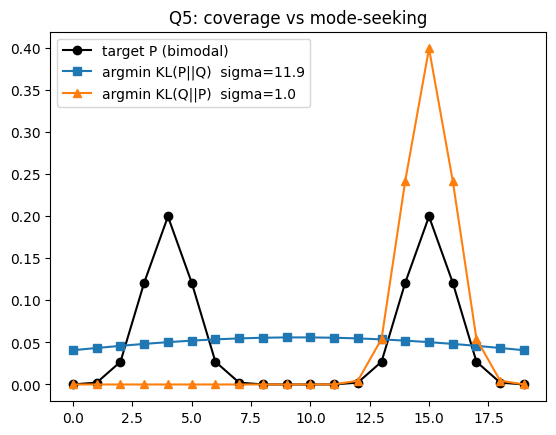

In [25]:
# ---- EXPERIMENT: fit a UNIMODAL family to a BIMODAL target, both KL directions (loop given) ----
bins = np.arange(20)
P = np.exp(-(bins-4)**2/2)/2 + np.exp(-(bins-15)**2/2)/2; P = P/P.sum()

def Qdist(mu, s):
    q = np.exp(-(bins-mu)**2/(2*s**2)); return q/q.sum()

kl_fn = my_kl if "Q5" not in FALLBACK else (lambda p, q: rel_entr(p, q).sum())
best_f, best_r = (np.inf, None, None), (np.inf, None, None)
for mu in np.arange(0, 20, 0.25):
    for s in np.arange(0.5, 12, 0.1):
        q = Qdist(mu, s)
        f = kl_fn(P, q)           # forward:  KL(P || Q)
        r = kl_fn(q, P)           # reverse:  KL(Q || P)
        if f < best_f[0]: best_f = (f, mu, s)
        if r < best_r[0]: best_r = (r, mu, s)

print(f"forward argmin: mu={best_f[1]}, sigma={best_f[2]:.2f} | reverse argmin: mu={best_r[1]}, sigma={best_r[2]:.2f}")
assert best_f[2] > best_r[2], "Q5 experiment assert FAILED - forward fit should be WIDER than reverse"
plt.plot(bins, P, "k-o", label="target P (bimodal)")
plt.plot(bins, Qdist(best_f[1], best_f[2]), "-s", label=f"argmin KL(P||Q)  sigma={best_f[2]:.1f}")
plt.plot(bins, Qdist(best_r[1], best_r[2]), "-^", label=f"argmin KL(Q||P)  sigma={best_r[2]:.1f}")
plt.legend(); plt.title("Q5: coverage vs mode-seeking"); plt.show()

**1.	Compare the fitted values of μ and σ produced by the two KL directions. How does each fitted distribution allocate probability across the two modes and the region between them? Explain the difference by identifying which distribution supplies the observations in each KL calculation.**

**2.	Cross-entropy training and KL-regularized RLHF place the observed or reference distribution in particular argument positions. Which behavior from your fitted distributions is relevant to each application, and what type of probability error does that direction penalize most strongly?**

**3.	In the distillation experiment, which KL direction better represents the requirement that the student should not assign very low probability to outcomes considered plausible by the teacher? Support your choice using both KL values from your results.**

---
## Question 6 (10 pts):

c:\Users\wages\AppData\Local\Programs\Python\Python311\Lib\site-packages\scanpy\neighbors\__init__.py:430: FutureWarning: The method obsm_keys is deprecated and will be removed in the future. Use obsm instead of obsm_keys. (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`)
  if "X_diffmap" in adata.obsm_keys():


{0.1: 3, 0.2: 4, 0.4: 4, 0.6: 7, 1.0: 8, 1.4: 10, 2.0: 18}


c:\Users\wages\AppData\Local\Programs\Python\Python311\Lib\site-packages\scanpy\neighbors\__init__.py:430: FutureWarning: The method obsm_keys is deprecated and will be removed in the future. Use obsm instead of obsm_keys. (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`)
  if "X_diffmap" in adata.obsm_keys():
c:\Users\wages\AppData\Local\Programs\Python\Python311\Lib\site-packages\scanpy\neighbors\__init__.py:430: FutureWarning: The method obsm_keys is deprecated and will be removed in the future. Use obsm instead of obsm_keys. (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`)
  if "X_diffmap" in adata.obsm_keys():
c:\Users\wages\AppData\Local\Programs\Python\Python311\Lib\site-packages\scanpy\neighbors\__init__.py:430: FutureWarning: The method obsm_keys is deprecated and will be removed in the future. Use obsm instead of obsm_keys. (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`)
  if "X_diffmap" in adata.obsm_keys():
c:\Users\wages\AppData\Local\Programs\Python\P

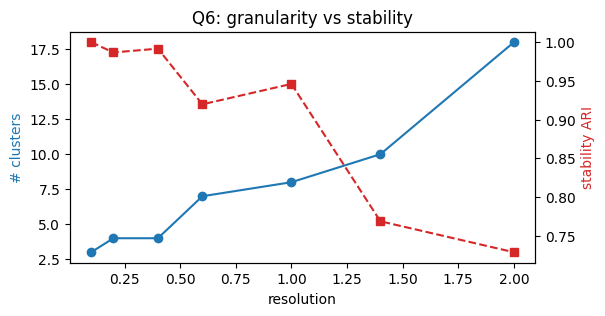

stability: {0.1: np.float64(1.0), 0.2: np.float64(0.987), 0.4: np.float64(0.992), 0.6: np.float64(0.92), 1.0: np.float64(0.946), 1.4: np.float64(0.768), 2.0: np.float64(0.728)}


In [30]:
sc.pp.neighbors(adata_hvg, n_neighbors=15, n_pcs=50)
sc.tl.umap(adata_hvg)
res_grid = [0.1, 0.2, 0.4, 0.6, 1.0, 1.4, 2.0]

# TODO(1): for each r in res_grid run Leiden with key_added=f"leiden_{r}" (newer scanpy: flavor="igraph", n_iterations=2)
# ____________________________________________
for r in res_grid:
    sc.tl.leiden(adata_hvg, resolution=r, key_added=f"leiden_{r}", flavor="igraph", n_iterations=2)

n_clusters = [adata_hvg.obs[f"leiden_{r}"].nunique() for r in res_grid]
print(dict(zip(res_grid, n_clusters)))

def stability_ari(r, frac=0.8, seed=0):
    """Two independent subsamples, cluster each, ARI on the shared cells."""
    rng = np.random.RandomState(seed)
    labs = []
    idx = [np.sort(rng.choice(adata_hvg.n_obs, int(frac*adata_hvg.n_obs), replace=False)) for _ in range(2)]
    for ii, s in zip(idx, [10, 20]):
        sub = adata_hvg[ii].copy()
        sc.pp.neighbors(sub, n_neighbors=15, n_pcs=50)
        # TODO(2): run Leiden on `sub` at resolution r, key_added="lab", random_state=s
        # ____________________________________________
        sc.tl.leiden(sub, resolution=r, key_added="lab", random_state=s)
        labs.append(dict(zip(ii, sub.obs["lab"].values)))
    common = np.intersect1d(idx[0], idx[1])
    return adjusted_rand_score([labs[0][c] for c in common], [labs[1][c] for c in common])

stab = [stability_ari(r) for r in res_grid]
fig, ax1 = plt.subplots(figsize=(6,3)); ax2 = ax1.twinx()
ax1.plot(res_grid, n_clusters, "o-", color="tab:blue"); ax1.set_ylabel("# clusters", color="tab:blue")
ax2.plot(res_grid, stab, "s--", color="tab:red"); ax2.set_ylabel("stability ARI", color="tab:red")
ax1.set_xlabel("resolution"); plt.title("Q6: granularity vs stability"); plt.show()
print("stability:", dict(zip(res_grid, np.round(stab, 3))))

**1.	Identify a range of resolutions in which the clustering is comparatively stable. Support your answer using both the ARI values and the corresponding numbers of clusters. What does this range justify and what decision does it not make automatically?**

**2.	If multiple resolutions have comparable stability, what task-specific consideration would you use to select among them? Explain why stability alone cannot determine the most useful level of clustering.**

---
## Question 7 (10 pts):

In [19]:
from sklearn.cluster import KMeans

def lloyd(X, init_centroids, max_iter=300):
    """Return (labels, centroids, inertia). Stop when centroids stop moving."""
    mu = init_centroids.copy()
    # TODO(1): implement the assign / update loop per the handout formulas
    while True:
        # Assign labels based on closest centroid
        distances = np.linalg.norm(X[:, np.newaxis] - mu, axis=2)
        labels = np.argmin(distances, axis=1)
        
        # Update centroids
        new_mu = np.array([X[labels == k].mean(axis=0) for k in range(mu.shape[0])])
        
        # Check for convergence
        if np.allclose(mu, new_mu):
            break
        
        mu = new_mu
    #return labels, centroids, and intertia
    inertia = np.sum((X - mu[labels]) ** 2)
    return labels, mu, inertia
    raise NotImplementedError

# ---- assert vs sklearn from the SAME init on synthetic blobs ----
from sklearn.datasets import make_blobs
Xb, _ = make_blobs(n_samples=600, centers=4, cluster_std=1.2, random_state=3)
rng = np.random.RandomState(0); init = Xb[rng.choice(len(Xb), 4, replace=False)]
lab_m, mu_m, in_m = lloyd(Xb, init)
km = KMeans(n_clusters=4, init=init, n_init=1, algorithm="lloyd").fit(Xb)
assert abs(in_m - km.inertia_) / km.inertia_ < 0.01, "Q7 assert FAILED - inertia mismatch"
print("Q7 assert PASSED | inertia:", round(float(in_m), 1))

Q7 assert PASSED | inertia: 1718.5


ARI(my k-means, leiden@1.0) = 0.642


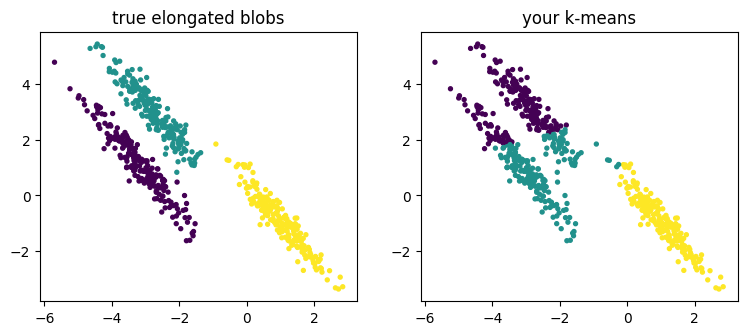

In [31]:
# ---- EXPERIMENT (given) ----
# (a) real data: your Lloyd vs Leiden
k = adata_hvg.obs["leiden_1.0"].nunique()
rng = np.random.RandomState(0); initZ = Z[rng.choice(len(Z), k, replace=False)]
lloyd_fn = lloyd if "Q7" not in FALLBACK else (lambda X, i, **kw: (KMeans(n_clusters=len(i), init=i, n_init=1).fit(X).labels_, None, None))
labZ = lloyd_fn(Z, initZ)[0]
print("ARI(my k-means, leiden@1.0) =", round(adjusted_rand_score(adata_hvg.obs["leiden_1.0"].values, labZ), 3))

# (b) anisotropic stress test
Xa, ya = make_blobs(n_samples=600, centers=3, random_state=170)
Xa = Xa @ np.array([[0.6, -0.64], [-0.4, 0.85]])          # shear -> elongated tilted blobs
rng = np.random.RandomState(2); inita = Xa[rng.choice(len(Xa), 3, replace=False)]
laba = lloyd_fn(Xa, inita)[0]
fig, ax = plt.subplots(1, 2, figsize=(9, 3.5))
ax[0].scatter(Xa[:,0], Xa[:,1], c=ya, s=8);  ax[0].set_title("true elongated blobs")
ax[1].scatter(Xa[:,0], Xa[:,1], c=laba, s=8); ax[1].set_title("your k-means")
plt.show()

**1.	Using the stress-test figure, describe geometrically how k-means divides the elongated clusters differently from the known partition. How does the squared-L2 distance to a centroid produce the pattern visible in your result?**

**2.	Why would replacing L2 distance with cosine distance while retaining the ordinary arithmetic-mean update make the assignment and update steps optimize different criteria? Explain how normalizing the observations and renormalizing each updated centroid produces a coherent spherical k-means procedure.**

---
## Question 8 (10 pts):

In [ ]:
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN

X_toy, _ = make_moons(n_samples=400, noise=0.06, random_state=0)
rng = np.random.RandomState(1)
X_toy = np.vstack([X_toy, rng.uniform(-1.5, 2.5, size=(40, 2))])

def my_dbscan(X, eps, min_samples):
    """Return labels: -1 = noise, 0..C-1 = clusters. Neighborhood includes the point itself."""
    # TODO(1): core-point test + BFS/stack expansion per the handout pseudocode
    raise NotImplementedError

mine = my_dbscan(X_toy, 0.12, 5)
skl  = DBSCAN(eps=0.12, min_samples=5).fit_predict(X_toy)
assert adjusted_rand_score(mine, skl) >= 0.95, "Q8 assert FAILED"
print("Q8 assert PASSED | clusters:", len(set(mine)) - (1 if -1 in mine else 0), "| noise:", int((mine == -1).sum()))

In [ ]:
# ---- EXPERIMENT (given): eps sweep + scale sabotage ----
db_fn = my_dbscan if "Q8" not in FALLBACK else (lambda X, e, m: DBSCAN(eps=e, min_samples=m).fit_predict(X))
eps_grid = np.round(np.arange(0.05, 0.42, 0.025), 3)
ncl, noi = [], []
for e in eps_grid:
    lab = db_fn(X_toy, e, 5)
    ncl.append(len(set(lab)) - (1 if -1 in lab else 0)); noi.append((lab == -1).mean())
fig, ax1 = plt.subplots(figsize=(6,3)); ax2 = ax1.twinx()
ax1.plot(eps_grid, ncl, "o-", color="tab:blue"); ax1.set_ylabel("# clusters", color="tab:blue")
ax2.plot(eps_grid, noi, "s--", color="tab:red"); ax2.set_ylabel("noise fraction", color="tab:red")
ax1.set_xlabel("eps"); plt.title("Q8: eps sweep"); plt.show()

X_bad = X_toy.copy(); X_bad[:, 0] *= 10        # sabotage: stretch x-axis 10x
lab_bad = db_fn(X_bad, 0.12, 5)
print("same eps after 10x x-stretch -> clusters:", len(set(lab_bad)) - (1 if -1 in lab_bad else 0),
      "| noise fraction:", round(float((lab_bad == -1).mean()), 3))

**1.	Identify a range of ε values for which the clustering structure is relatively stable. Cite the cluster counts and noise fractions from your results. Using core-point expansion, explain what happens mechanically when ε is below and above this range.**

**2.	Compare the DBSCAN results before and after multiplying the horizontal coordinate by 10. Cite the resulting cluster counts and noise fractions. Why did changing the scale of one feature affect the ε-neighborhoods, and which preprocessing principle from Question 1 and Lecture 2.2 does this demonstrate?**

---
## Question 9 (10 pts):

LOCAL  outlier rank -> kNN-dist: 202 | LOF: 1
GLOBAL outlier rank -> kNN-dist: 1 | LOF: 2
Q9 assert PASSED


C:\Users\wages\AppData\Local\Temp\ipykernel_11664\1281989250.py:12: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.sum(A**2, axis=1)[:, np.newaxis] + np.sum(B**2, axis=1) - 2 * np.dot(A, B.T))


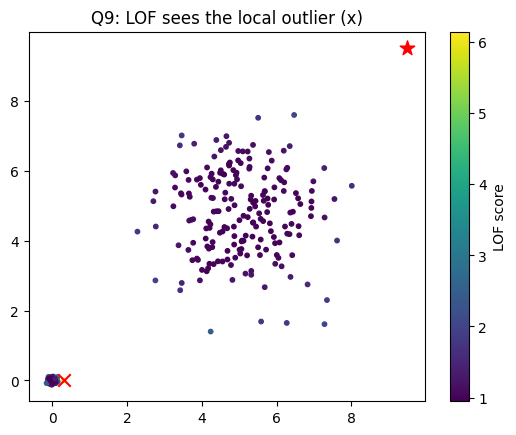

In [33]:
def knn_dist_score(X, k=10):
    """score(x) = mean distance to the k nearest OTHER points (global density proxy)."""
    # TODO(1): use pairwise_l2 (Q3), sort each row, average columns 1..k
    D = pairwise_l2(X, X)
    np.fill_diagonal(D, np.inf)  # Exclude self-distance
    sorted_distances = np.sort(D, axis=1)
    score = np.mean(sorted_distances[:, 1:k+1], axis=1)
    return score    
    raise NotImplementedError

def pairwise_l2(A, B):
    return np.sqrt(np.sum(A**2, axis=1)[:, np.newaxis] + np.sum(B**2, axis=1) - 2 * np.dot(A, B.T))

# ---- synthetic dual-density scene (given) ----
rng = np.random.RandomState(7)
dense  = rng.normal([0, 0], 0.05, size=(200, 2))
sparse = rng.normal([5, 5], 1.2,  size=(200, 2))
Xs = np.vstack([dense, sparse, [[0.3, 0.0]], [[9.5, 9.5]]])
i_local, i_global = 400, 401

s_knn = knn_dist_score(Xs, 10)
lof = LocalOutlierFactor(n_neighbors=10); lof.fit(Xs); s_lof = -lof.negative_outlier_factor_
rank = lambda s, i: int((s > s[i]).sum()) + 1
print("LOCAL  outlier rank -> kNN-dist:", rank(s_knn, i_local),  "| LOF:", rank(s_lof, i_local))
print("GLOBAL outlier rank -> kNN-dist:", rank(s_knn, i_global), "| LOF:", rank(s_lof, i_global))
assert rank(s_lof, i_local) <= 5 < rank(s_knn, i_local), "Q9 assert FAILED - LOF should catch the local outlier, kNN-dist should not"
print("Q9 assert PASSED")
plt.scatter(Xs[:,0], Xs[:,1], c=s_lof, s=10, cmap="viridis"); plt.colorbar(label="LOF score")
plt.scatter(*Xs[i_local], marker="x", c="red", s=80); plt.scatter(*Xs[i_global], marker="*", c="red", s=120)
plt.title("Q9: LOF sees the local outlier (x)"); plt.show()

In [37]:
# ---- real data: three-way comparison (given except the threshold) ----
import pandas as pd
s_knn_Z = knn_dist_score(Z, 20) if "Q9" not in FALLBACK else NearestNeighbors(n_neighbors=21).fit(Z).kneighbors(Z)[0][:,1:].mean(1)
knn_flag = s_knn_Z > np.quantile(s_knn_Z, 0.98)
lofZ = LocalOutlierFactor(n_neighbors=20); lof_flag = lofZ.fit_predict(Z) == -1
mt_thresh = 10   # TODO(2): pick 10-20
mt_flag = adata_hvg.obs["pct_counts_mt"].values > mt_thresh
print(pd.crosstab(pd.Series(lof_flag, name="LOF"), [pd.Series(knn_flag, name="kNN-dist"), pd.Series(mt_flag, name=f"mt>{mt_thresh}")]))

kNN-dist False       True       
mt>10    False True  False True 
LOF                             
False     2592     2    16     0
True        50     2    36     2


C:\Users\wages\AppData\Local\Temp\ipykernel_11664\1281989250.py:12: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.sum(A**2, axis=1)[:, np.newaxis] + np.sum(B**2, axis=1) - 2 * np.dot(A, B.T))


**1.	Compare the four anomaly ranks from the synthetic experiment. Why do the global kNN-distance score and LOF treat the planted local outlier differently? Identify which observations determine the comparison scale used by each method.**

**2.	In one sentence each, state the anomaly definition encoded by the global kNN-distance score, LOF, and the mitochondrial-percentage threshold. Based on your synthetic ranks and real-data contingency table, which evidence would you use when deciding whether a cell should be removed before clustering? Explain why no single flag should automatically be treated as proof that a cell is invalid.**

---
## Question 10 (10 pts):

**Comment 1:**

**Comment 2:**

**Comment 3:**